=== Step 1: Sampling rows per class from CSV in chunks ===

Class distribution after sampling:
type
5    300000
6     20000
9     20000
3     20000
7     20000
2     20000
0     20000
1     20000
8     20000
4      1043
Name: count, dtype: int64

Training Improved Decision Tree...


===== Multiclass Decision Tree Results (Averages) =====
Accuracy: 0.9904
F1 Score: 0.9905
Recall: 0.9904
Precision: 0.9907
Training Time: 1.81 seconds

=== Generating Confusion Matrix Heatmap ===


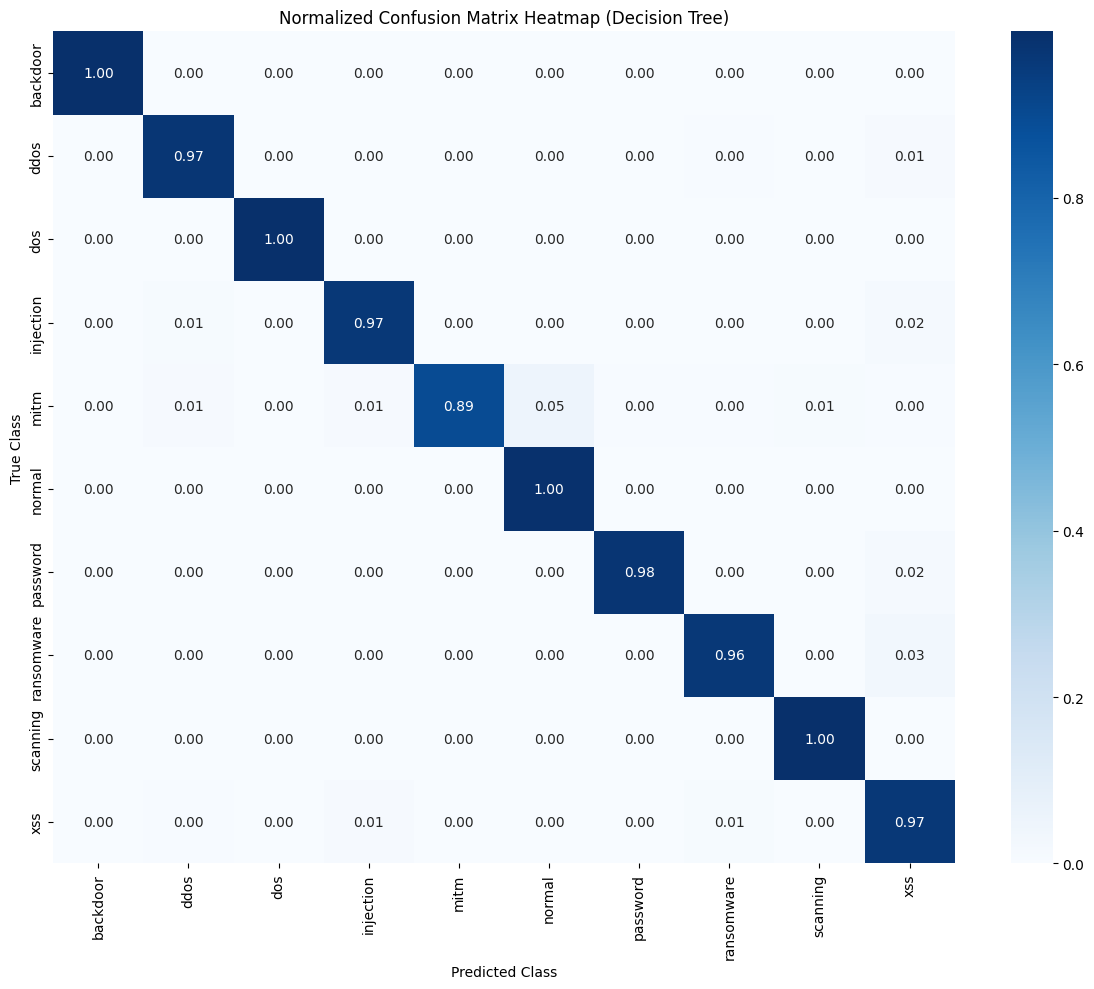


=== Detailed Classification Report (Per-Class Metrics) ===
              precision    recall  f1-score   support

    backdoor     0.9998    0.9998    0.9998      4000
        ddos     0.9656    0.9750    0.9703      4000
         dos     0.9988    0.9992    0.9990      4000
   injection     0.9738    0.9680    0.9709      4000
        mitm     0.8202    0.8947    0.8558       209
      normal     0.9989    0.9955    0.9972     60000
    password     0.9859    0.9795    0.9827      4000
  ransomware     0.9834    0.9647    0.9740      4000
    scanning     0.9955    0.9985    0.9970      4000
         xss     0.9073    0.9663    0.9358      4000

    accuracy                         0.9904     92209
   macro avg     0.9629    0.9741    0.9683     92209
weighted avg     0.9907    0.9904    0.9905     92209

--- Script Execution Complete ---


In [1]:
#DT
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    recall_score, 
    precision_score, 
    confusion_matrix,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier

# =======================
# File path
# =======================
input_file = r"D:\Dataset_Project\dataset_fyp\10Features_multiclass_process\preprocess_merged_multiclass.csv"

# =======================
# Class sampling limits (Define class names for later steps)
# =======================
class_limits = {
    0: 20000,   # backdoor
    1: 20000,   # ddos
    2: 20000,   # dos
    3: 20000,   # injection
    4: 1043,    # mitm
    5: 300000,  # normal
    6: 20000,   # password
    7: 20000,   # ransomware
    8: 20000,   # scanning
    9: 20000,   # xss
}
# Define class labels for visualization and reporting
class_labels = {
    0: 'backdoor', 1: 'ddos', 2: 'dos', 3: 'injection', 
    4: 'mitm', 5: 'normal', 6: 'password', 7: 'ransomware', 
    8: 'scanning', 9: 'xss',
}
target_names = [class_labels[i] for i in sorted(class_labels.keys())]

chunksize = 100000

# ###############################################################
# STEP 1: Data Sampling (Handling large CSV in chunks)
# ###############################################################
print("=== Step 1: Sampling rows per class from CSV in chunks ===")

selected_rows = {cls: [] for cls in class_limits}
row_count = {cls: 0 for cls in class_limits}

try:
    for chunk in pd.read_csv(input_file, chunksize=chunksize):
        for cls, limit in class_limits.items():
            # Already reached limit
            if row_count[cls] >= limit:
                continue

            cls_rows = chunk[chunk['type'] == cls]

            if cls_rows.empty:
                continue

            needed = limit - row_count[cls]
            take_rows = cls_rows.iloc[:needed]

            selected_rows[cls].append(take_rows)
            row_count[cls] += len(take_rows)

    # Combine all sampled rows
    df_sample = pd.concat([pd.concat(rows) for rows in selected_rows.values()],
                          ignore_index=True)

    # Shuffle dataset
    df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

except FileNotFoundError:
    print(f"\nERROR: File not found at path: {input_file}")
    print("Please ensure the file path is correct and accessible.")
    exit()


# ###############################################################
# STEP 2: Prepare X and y
# ###############################################################
y = df_sample['type']
X = df_sample.drop(columns=['type'])

print("\nClass distribution after sampling:")
print(y.value_counts())

# ###############################################################
# STEP 3: Train-test split
# ###############################################################
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nTraining Improved Decision Tree...\n")

# ###############################################################
# STEP 4: Decision Tree Training and Prediction
# ###############################################################
model = DecisionTreeClassifier(
    criterion='entropy',
    class_weight='balanced',
    random_state=42,

    # Improved Hyperparameters
    max_depth=20,
    min_samples_split=6,
    min_samples_leaf=2,
    max_features=None,
    min_impurity_decrease=1e-6,
)

start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time

# Predict
y_pred = model.predict(X_test)

# ###############################################################
# STEP 5: Core Metrics Calculation
# ###############################################################
accuracy = accuracy_score(y_test, y_pred)
# We use 'weighted' average to account for class imbalance (even after sampling)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0) 
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)

cm = confusion_matrix(y_test, y_pred)

print("\n===== Multiclass Decision Tree Results (Averages) =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Training Time: {train_time:.2f} seconds")

# ###############################################################
# STEP 6: Visualization and Detailed Reporting
# ###############################################################

# --- 1. Confusion Matrix Heatmap ---
print("\n=== Generating Confusion Matrix Heatmap ===")

# Normalize the confusion matrix for visual interpretation (rows sum to 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f', # Display normalized values with 2 decimal places
    cmap='Blues', 
    cbar=True,
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title('Normalized Confusion Matrix Heatmap (Decision Tree)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout() # Adjust plot to fit labels
plt.show() 

# --- 2. Classification Metric Report ---
print("\n=== Detailed Classification Report (Per-Class Metrics) ===")

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4,
    zero_division=0
)
print(report)

print("--- Script Execution Complete ---")

=== Step 1: Sampling rows per class from CSV in chunks ===

Class distribution after correct sampling:
type
5    300000
6     20000
9     20000
3     20000
7     20000
2     20000
0     20000
1     20000
8     20000
4      1043
Name: count, dtype: int64

Training Optimized AdaBoost...



C:\Users\60105\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



===== AdaBoost Results (Averages) =====
Accuracy: 0.9920
F1 Score: 0.9921
Recall: 0.9920
Precision: 0.9922
Training Time: 102.49 seconds

=== Generating Confusion Matrix Heatmap ===


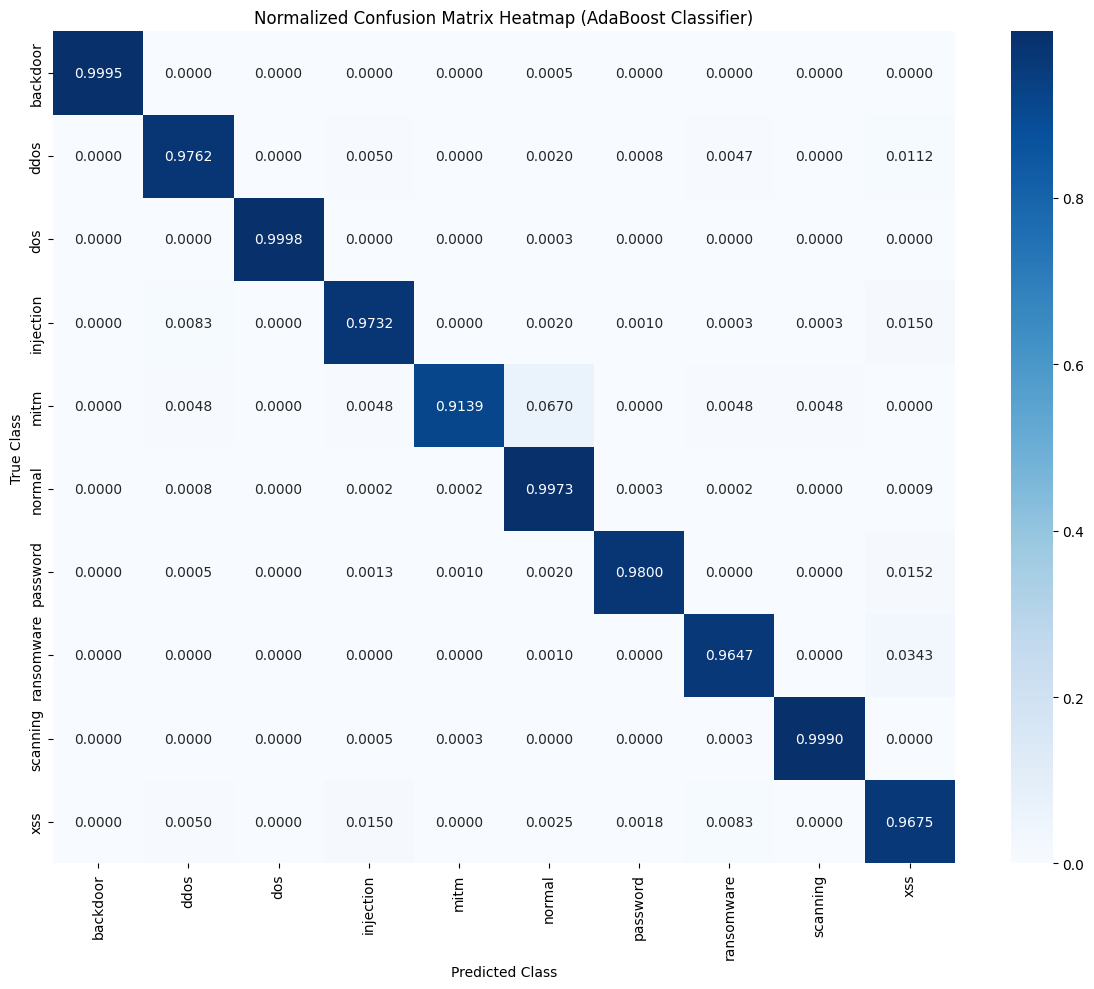


=== Detailed Classification Report (Per-Class Metrics) ===
              precision    recall  f1-score   support

    backdoor     0.9997    0.9995    0.9996      4000
        ddos     0.9733    0.9762    0.9748      4000
         dos     0.9998    0.9998    0.9998      4000
   injection     0.9752    0.9732    0.9742      4000
        mitm     0.9227    0.9139    0.9183       209
      normal     0.9991    0.9973    0.9982     60000
    password     0.9914    0.9800    0.9857      4000
  ransomware     0.9834    0.9647    0.9740      4000
    scanning     0.9990    0.9990    0.9990      4000
         xss     0.9158    0.9675    0.9409      4000

    accuracy                         0.9920     92209
   macro avg     0.9759    0.9771    0.9764     92209
weighted avg     0.9922    0.9920    0.9921     92209

--- Script Execution Complete ---


In [6]:
#Adaboost
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    recall_score, 
    precision_score, 
    confusion_matrix,
    classification_report
)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# =======================
# File path
# =======================
input_file = r"D:\Dataset_Project\dataset_fyp\10Features_multiclass_process\preprocess_merged_multiclass.csv"

# =======================
# Class sampling limits and Labels
# =======================
class_limits = {
    0: 20000,   # backdoor
    1: 20000,   # ddos
    2: 20000,   # dos
    3: 20000,   # injection
    4: 1043,    # mitm
    5: 300000,  # normal
    6: 20000,   # password
    7: 20000,   # ransomware
    8: 20000,   # scanning
    9: 20000,   # xss
}

# Define class labels for visualization and reporting
class_labels = {
    0: 'backdoor', 1: 'ddos', 2: 'dos', 3: 'injection', 
    4: 'mitm', 5: 'normal', 6: 'password', 7: 'ransomware', 
    8: 'scanning', 9: 'xss',
}
target_names = [class_labels[i] for i in sorted(class_labels.keys())]

chunksize = 100000

# ###############################################################
# STEP 1: Data Sampling (Handling large CSV in chunks)
# ###############################################################
print("=== Step 1: Sampling rows per class from CSV in chunks ===")

selected_rows = {cls: [] for cls in class_limits}
row_count = {cls: 0 for cls in class_limits}

try:
    for chunk in pd.read_csv(input_file, chunksize=chunksize):
        for cls, limit in class_limits.items():
            # Already reached limit
            if row_count[cls] >= limit:
                continue

            cls_rows = chunk[chunk['type'] == cls]
            if cls_rows.empty:
                continue

            needed = limit - row_count[cls]
            take_rows = cls_rows.iloc[:needed]

            selected_rows[cls].append(take_rows)
            row_count[cls] += len(take_rows)

    # Combine all sampled rows
    df_sample = pd.concat([pd.concat(rows) for rows in selected_rows.values()],
                          ignore_index=True)

    # Shuffle dataset
    df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

except FileNotFoundError:
    print(f"\nERROR: File not found at path: {input_file}")
    print("Please ensure the file path is correct and accessible.")
    exit()


# ###############################################################
# STEP 2: Prepare X and y
# ###############################################################
y = df_sample['type']
X = df_sample.drop(columns=['type'])

print("\nClass distribution after correct sampling:")
print(y.value_counts())

# ###############################################################
# STEP 3: Train-test split
# ###############################################################
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nTraining Optimized AdaBoost...\n")

# ###############################################################
# STEP 4 & 5: AdaBoost Training and Prediction
# ###############################################################
# Base Decision Tree for AdaBoost
base_dt = DecisionTreeClassifier(
    criterion='entropy',
    class_weight='balanced',
    random_state=42,

    # Improved hyperparameters
    max_depth=17,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    min_impurity_decrease=1e-7,
)

# Optimized AdaBoost Model
model = AdaBoostClassifier(
    estimator=base_dt,
    n_estimators=7000,
    learning_rate=0.1,
    algorithm='SAMME',
    random_state=42
)





start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = model.predict(X_test)

# ###############################################################
# STEP 6: Core Metrics Calculation
# ###############################################################
accuracy = accuracy_score(y_test, y_pred)
# Use zero_division=0 to handle cases where a class has no predictions/true samples
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0) 
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)

cm = confusion_matrix(y_test, y_pred)

print("\n===== AdaBoost Results (Averages) =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Training Time: {train_time:.2f} seconds")

# ###############################################################
# STEP 7: Visualization and Detailed Reporting
# ###############################################################

# --- 1. Confusion Matrix Heatmap ---
print("\n=== Generating Confusion Matrix Heatmap ===")

# Normalize the confusion matrix (rows sum to 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f', # Increased precision to 4 decimal places
    cmap='Blues', 
    cbar=True,
    xticklabels=target_names,
    yticklabels=target_names
)


plt.title('Normalized Confusion Matrix Heatmap (AdaBoost Classifier)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show() 

# --- 2. Classification Metric Report ---
print("\n=== Detailed Classification Report (Per-Class Metrics) ===")

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4, # Increased precision to 4 decimal places
    zero_division=0
)
print(report)

print("--- Script Execution Complete ---")

=== Step 1: Sampling rows per class from CSV in chunks ===

Class distribution in sampled dataset:
type
5    300000
6     20000
9     20000
3     20000
7     20000
2     20000
0     20000
1     20000
8     20000
4      1043
Name: count, dtype: int64

Training Gradient Boosted Trees (GBT) with sample weights...


===== Gradient Boosted Trees Results (Weighted Multiclass) =====
Accuracy: 0.9920
F1 Score: 0.9921
Recall: 0.9920
Precision: 0.9923
Training Time: 4813.00 seconds

=== Generating Confusion Matrix Heatmap ===


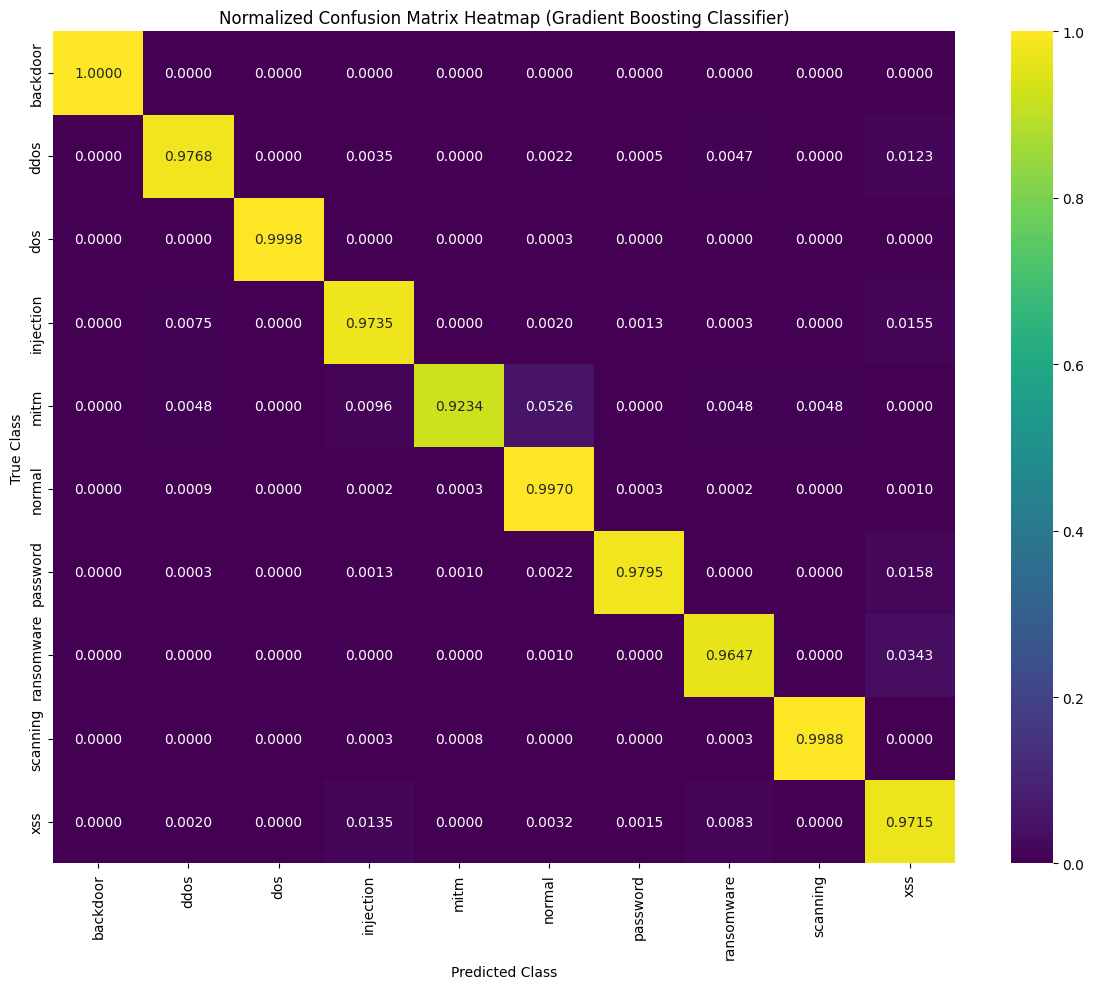


=== Detailed Classification Report (Per-Class Metrics) ===
              precision    recall  f1-score   support

    backdoor     1.0000    1.0000    1.0000      4000
        ddos     0.9765    0.9768    0.9766      4000
         dos     1.0000    0.9998    0.9999      4000
   injection     0.9774    0.9735    0.9755      4000
        mitm     0.8853    0.9234    0.9040       209
      normal     0.9991    0.9970    0.9981     60000
    password     0.9921    0.9795    0.9858      4000
  ransomware     0.9834    0.9647    0.9740      4000
    scanning     0.9992    0.9988    0.9990      4000
         xss     0.9126    0.9715    0.9411      4000

    accuracy                         0.9920     92209
   macro avg     0.9726    0.9785    0.9754     92209
weighted avg     0.9923    0.9920    0.9921     92209

--- Script Execution Complete ---


In [7]:
#GBT
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    recall_score, 
    precision_score, 
    confusion_matrix,
    classification_report
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight # For balanced weighting

# =======================
# File and parameters
# =======================
input_file = r"D:\Dataset_Project\dataset_fyp\10Features_multiclass_process\preprocess_merged_multiclass.csv"
chunksize = 80000 

class_limits = {
    0: 20000,   # backdoor
    1: 20000,   # ddos
    2: 20000,   # dos
    3: 20000,   # injection
    4: 1043,    # mitm
    5: 300000,  # normal
    6: 20000,   # password
    7: 20000,   # ransomware
    8: 20000,   # scanning
    9: 20000,   # xss
}

# Define class labels for visualization and reporting
class_labels = {
    0: 'backdoor', 1: 'ddos', 2: 'dos', 3: 'injection', 
    4: 'mitm', 5: 'normal', 6: 'password', 7: 'ransomware', 
    8: 'scanning', 9: 'xss',
}
target_names = [class_labels[i] for i in sorted(class_labels.keys())]

# ###############################################################
# STEP 1: Data Sampling (Handling large CSV in chunks)
# ###############################################################
print("=== Step 1: Sampling rows per class from CSV in chunks ===")
selected_rows = {cls: [] for cls in class_limits}
row_count = {cls: 0 for cls in class_limits}

try:
    for chunk in pd.read_csv(input_file, chunksize=chunksize):
        for cls, limit in class_limits.items():
            if row_count[cls] >= limit:
                continue
            cls_rows = chunk[chunk['type'] == cls]
            if cls_rows.empty:
                continue
            needed = limit - row_count[cls]
            take_rows = cls_rows.iloc[:needed]
            selected_rows[cls].append(take_rows)
            row_count[cls] += len(take_rows)

    df_sample = pd.concat([pd.concat(rows) for rows in selected_rows.values()],
                          ignore_index=True)
    df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

except FileNotFoundError:
    print(f"\nERROR: File not found at path: {input_file}")
    print("Please ensure the file path is correct and accessible.")
    exit()

# ###############################################################
# STEP 2: Prepare X and y
# ###############################################################
y = df_sample['type']
X = df_sample.drop(columns=['type'])

print("\nClass distribution in sampled dataset:")
print(y.value_counts())

# ###############################################################
# STEP 3: Train-test split
# ###############################################################
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ###############################################################
# STEP 4: Compute sample weights for imbalance
# ###############################################################
# This computes weights inverse to the class frequency in y_train
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

# ###############################################################
# STEP 5: Gradient Boosted Trees (Weighted) Training
# ###############################################################
model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    max_features='sqrt',
    loss='log_loss',
    random_state=42
)

print("\nTraining Gradient Boosted Trees (GBT) with sample weights...\n")
start_time = time.time()
# Apply the weights during the fit method
model.fit(X_train, y_train, sample_weight=sample_weight)
train_time = time.time() - start_time

# ###############################################################
# STEP 6: Predict & Metrics
# ###############################################################
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
# Use zero_division=0 and 'weighted' average
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("\n===== Gradient Boosted Trees Results (Weighted Multiclass) =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Training Time: {train_time:.2f} seconds")


# ###############################################################
# STEP 7: Visualization and Detailed Reporting
# ###############################################################

# --- 1. Confusion Matrix Heatmap ---
print("\n=== Generating Confusion Matrix Heatmap ===")

# Normalize the confusion matrix (rows sum to 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f', # Increased precision
    cmap='viridis',
    cbar=True,
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title('Normalized Confusion Matrix Heatmap (Gradient Boosting Classifier)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show() 

# --- 2. Classification Metric Report ---
print("\n=== Detailed Classification Report (Per-Class Metrics) ===")

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4, # Increased precision
    zero_division=0
)
print(report)

print("--- Script Execution Complete ---")

=== Step 1: Sampling rows per class from CSV in chunks ===

Class distribution in sampled dataset:
type
5    300000
6     20000
9     20000
3     20000
7     20000
2     20000
0     20000
1     20000
8     20000
4      1043
Name: count, dtype: int64

Training XGBoost (Optimized Multiclass)...


===== XGBoost Results (Multiclass) =====
Accuracy: 0.9921
F1 Score: 0.9922
Recall: 0.9921
Precision: 0.9924
Training Time: 270.62 seconds

=== Generating Confusion Matrix Heatmap ===


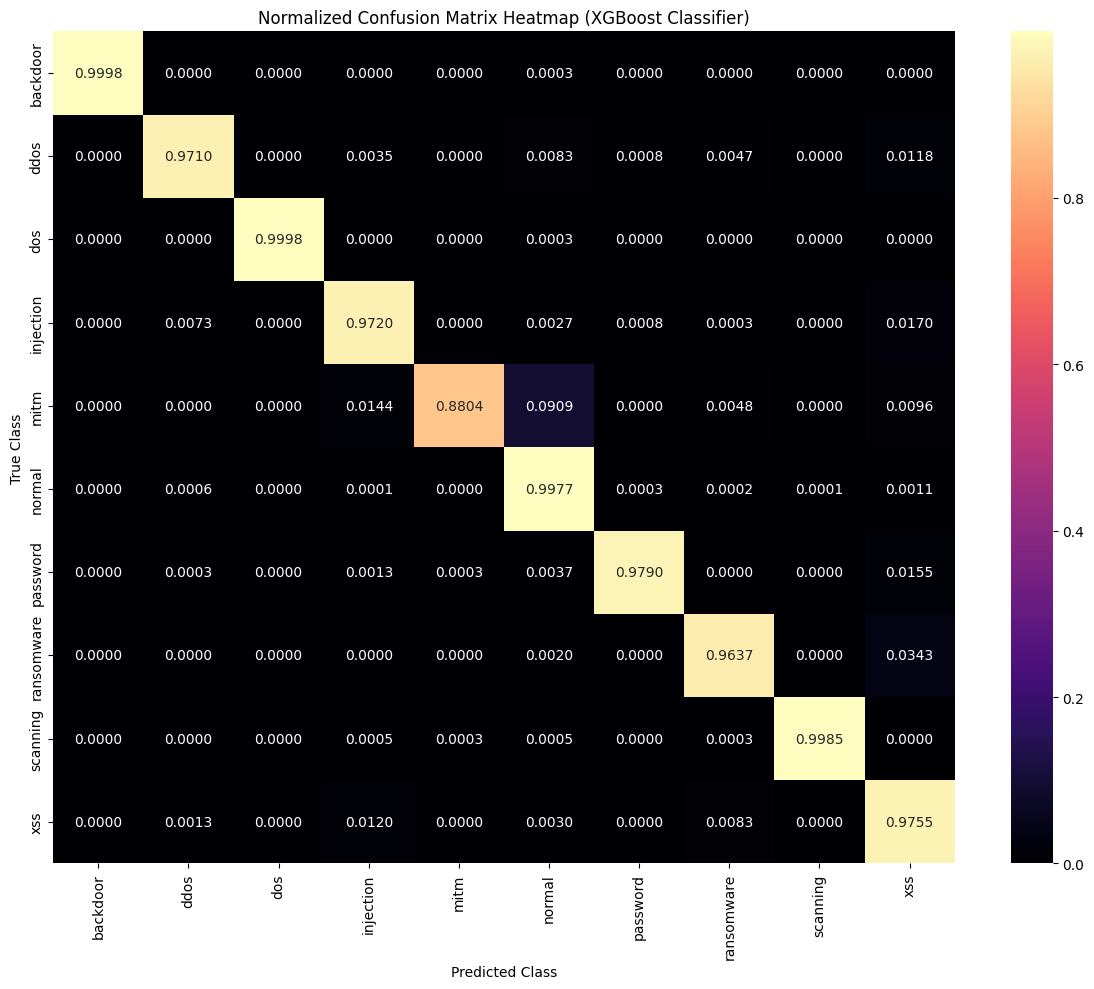


=== Detailed Classification Report (Per-Class Metrics) ===
              precision    recall  f1-score   support

    backdoor     1.0000    0.9998    0.9999      4000
        ddos     0.9823    0.9710    0.9766      4000
         dos     0.9998    0.9998    0.9998      4000
   injection     0.9811    0.9720    0.9765      4000
        mitm     0.9787    0.8804    0.9270       209
      normal     0.9983    0.9977    0.9980     60000
    password     0.9939    0.9790    0.9864      4000
  ransomware     0.9834    0.9637    0.9735      4000
    scanning     0.9992    0.9985    0.9989      4000
         xss     0.9106    0.9755    0.9419      4000

    accuracy                         0.9921     92209
   macro avg     0.9827    0.9737    0.9778     92209
weighted avg     0.9924    0.9921    0.9922     92209

--- Script Execution Complete ---


In [8]:
#XGB
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    recall_score, 
    precision_score, 
    confusion_matrix,
    classification_report
)
from xgboost import XGBClassifier

# =======================
# File and parameters
# =======================
input_file = r"D:\Dataset_Project\dataset_fyp\10Features_multiclass_process\preprocess_merged_multiclass.csv"
chunksize = 80000 

# Maximum rows per class
class_limits = {
    0: 20000,   # backdoor
    1: 20000,   # ddos
    2: 20000,   # dos
    3: 20000,   # injection
    4: 1043,    # mitm
    5: 300000,  # normal
    6: 20000,   # password
    7: 20000,   # ransomware
    8: 20000,   # scanning
    9: 20000,   # xss
}

# Define class labels for visualization and reporting
class_labels = {
    0: 'backdoor', 1: 'ddos', 2: 'dos', 3: 'injection', 
    4: 'mitm', 5: 'normal', 6: 'password', 7: 'ransomware', 
    8: 'scanning', 9: 'xss',
}
target_names = [class_labels[i] for i in sorted(class_labels.keys())]

# ###############################################################
# STEP 1: Data Sampling (Handling large CSV in chunks)
# ###############################################################
print("=== Step 1: Sampling rows per class from CSV in chunks ===")

selected_rows = {cls: [] for cls in class_limits}
row_count = {cls: 0 for cls in class_limits} 

try:
    for chunk in pd.read_csv(input_file, chunksize=chunksize):
        for cls, limit in class_limits.items():
            if row_count[cls] >= limit:
                continue

            cls_rows = chunk[chunk['type'] == cls]

            if cls_rows.empty:
                continue

            needed = limit - row_count[cls]
            take_rows = cls_rows.iloc[:needed]

            selected_rows[cls].append(take_rows)
            row_count[cls] += len(take_rows)

    # Combine all sampled rows
    df_sample = pd.concat([pd.concat(rows) for rows in selected_rows.values()],
                          ignore_index=True)

    # Shuffle dataset
    df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

except FileNotFoundError:
    print(f"\nERROR: File not found at path: {input_file}")
    print("Please ensure the file path is correct and accessible.")
    exit()

# ###############################################################
# STEP 2: Prepare X and y
# ###############################################################
y = df_sample['type']
X = df_sample.drop(columns=['type'])

print("\nClass distribution in sampled dataset:")
print(y.value_counts())

# ###############################################################
# STEP 3: Train-test split
# ###############################################################
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ###############################################################
# STEP 4: XGBoost (Multiclass) Training
# ###############################################################
model = XGBClassifier(
    objective="multi:softprob",
    num_class=10,
    tree_method="hist",
    booster="gbtree",
    
    # Optimized Hyperparameters
    n_estimators=800,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=1,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    eval_metric="mlogloss" # Multi-class log loss metric
)

print("\nTraining XGBoost (Optimized Multiclass)...\n")

start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time

# Predict
y_pred = model.predict(X_test)

# ###############################################################
# STEP 5: Core Metrics Calculation
# ###############################################################
accuracy = accuracy_score(y_test, y_pred)
# Use zero_division=0 and 'weighted' average
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
cm = confusion_matrix(y_test, y_pred)

# ###############################################################
# STEP 6: Visualization and Detailed Reporting
# ###############################################################

print("\n===== XGBoost Results (Multiclass) =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Training Time: {train_time:.2f} seconds")


# --- 1. Confusion Matrix Heatmap ---
print("\n=== Generating Confusion Matrix Heatmap ===")

# Normalize the confusion matrix (rows sum to 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f', # Increased precision to 4 decimal places
    cmap='magma', # New color map
    cbar=True,
    xticklabels=target_names,
    yticklabels=target_names
)


plt.title('Normalized Confusion Matrix Heatmap (XGBoost Classifier)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show() 

# --- 2. Classification Metric Report ---
print("\n=== Detailed Classification Report (Per-Class Metrics) ===")

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4, # Increased precision to 4 decimal places
    zero_division=0
)
print(report)

print("--- Script Execution Complete ---")

=== Step 1: Sampling rows per class from CSV in chunks ===

Class distribution in sampled dataset:
type
5    300000
6     20000
9     20000
3     20000
7     20000
2     20000
0     20000
1     20000
8     20000
4      1043
Name: count, dtype: int64

Training LightGBM (Optimized Multiclass)...

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014039 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1792
[LightGBM] [Info] Number of data points in the train set: 368834, number of used features: 10
[LightGBM] [Info] Start training from score -3.137758
[LightGBM] [Info] Start training from score -3.13775

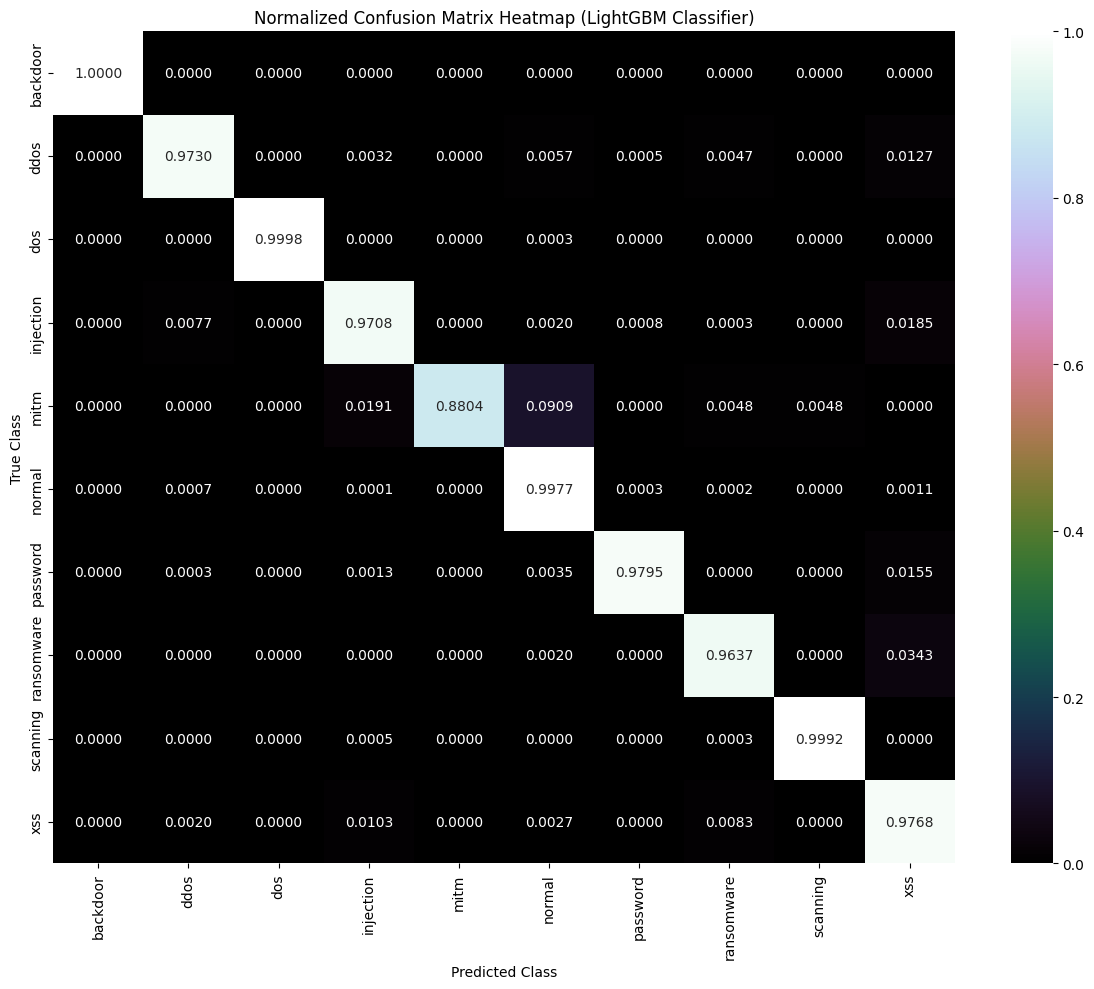


=== Detailed Classification Report (Per-Class Metrics) ===
              precision    recall  f1-score   support

    backdoor     1.0000    1.0000    1.0000      4000
        ddos     0.9796    0.9730    0.9763      4000
         dos     1.0000    0.9998    0.9999      4000
   injection     0.9828    0.9708    0.9767      4000
        mitm     0.9892    0.8804    0.9316       209
      normal     0.9986    0.9977    0.9981     60000
    password     0.9942    0.9795    0.9868      4000
  ransomware     0.9834    0.9637    0.9735      4000
    scanning     0.9992    0.9992    0.9992      4000
         xss     0.9097    0.9768    0.9420      4000

    accuracy                         0.9923     92209
   macro avg     0.9837    0.9741    0.9784     92209
weighted avg     0.9925    0.9923    0.9923     92209

--- Script Execution Complete ---


In [9]:
#LGBM
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    recall_score, 
    precision_score, 
    confusion_matrix,
    classification_report
)
from lightgbm import LGBMClassifier

# =======================
# File and parameters
# =======================
input_file = r"D:\Dataset_Project\dataset_fyp\10Features_multiclass_process\preprocess_merged_multiclass.csv"
chunksize = 80000 

# Maximum rows per class
class_limits = {
    0: 20000,   # backdoor
    1: 20000,   # ddos
    2: 20000,   # dos
    3: 20000,   # injection
    4: 1043,    # mitm
    5: 300000,  # normal
    6: 20000,   # password
    7: 20000,   # ransomware
    8: 20000,   # scanning
    9: 20000,   # xss
}

# Define class labels for visualization and reporting
class_labels = {
    0: 'backdoor', 1: 'ddos', 2: 'dos', 3: 'injection', 
    4: 'mitm', 5: 'normal', 6: 'password', 7: 'ransomware', 
    8: 'scanning', 9: 'xss',
}
target_names = [class_labels[i] for i in sorted(class_labels.keys())]

# ###############################################################
# STEP 1: Data Sampling (Handling large CSV in chunks)
# ###############################################################
print("=== Step 1: Sampling rows per class from CSV in chunks ===")

selected_rows = {cls: [] for cls in class_limits}
row_count = {cls: 0 for cls in class_limits} 

try:
    for chunk in pd.read_csv(input_file, chunksize=chunksize):
        for cls, limit in class_limits.items():
            if row_count[cls] >= limit:
                continue

            cls_rows = chunk[chunk['type'] == cls]

            if cls_rows.empty:
                continue

            needed = limit - row_count[cls]
            take_rows = cls_rows.iloc[:needed]

            selected_rows[cls].append(take_rows)
            row_count[cls] += len(take_rows)

    # Combine all sampled rows
    df_sample = pd.concat([pd.concat(rows) for rows in selected_rows.values()],
                          ignore_index=True)

    # Shuffle dataset
    df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

except FileNotFoundError:
    print(f"\nERROR: File not found at path: {input_file}")
    print("Please ensure the file path is correct and accessible.")
    exit()

# ###############################################################
# STEP 2: Prepare X and y
# ###############################################################
y = df_sample['type']
X = df_sample.drop(columns=['type'])

print("\nClass distribution in sampled dataset:")
print(y.value_counts())

# ###############################################################
# STEP 3: Train-test split
# ###############################################################
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ###############################################################
# STEP 4: Optimized LightGBM Model (Multiclass) Training
# ###############################################################
model = LGBMClassifier(
    objective='multiclass',
    num_class=10,
    boosting_type='gbdt',

    # FAST + ACCURATE configuration
    n_estimators=400,
    learning_rate=0.07,
    max_depth=-1,           # leaf-wise tree growth (LGBM default/strength)
    num_leaves=60,
    min_data_in_leaf=30,
    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0,
    reg_lambda=1,

    n_jobs=-1,
    random_state=42
)

print("\nTraining LightGBM (Optimized Multiclass)...\n")
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time

# Predict
y_pred = model.predict(X_test)

# ###############################################################
# STEP 5: Core Metrics Calculation
# ###############################################################
accuracy = accuracy_score(y_test, y_pred)
# Use zero_division=0 and 'weighted' average
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
cm = confusion_matrix(y_test, y_pred)

# ###############################################################
# STEP 6: Visualization and Detailed Reporting
# ###############################################################

print("\n===== LightGBM Results (Multiclass) =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Training Time: {train_time:.2f} seconds")


# --- 1. Confusion Matrix Heatmap ---
print("\n=== Generating Confusion Matrix Heatmap ===")
# Normalize the confusion matrix (rows sum to 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f', # Increased precision to 4 decimal places
    cmap='cubehelix', # New color map
    cbar=True,
    xticklabels=target_names,
    yticklabels=target_names
)


plt.title('Normalized Confusion Matrix Heatmap (LightGBM Classifier)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show() 

# --- 2. Classification Metric Report ---
print("\n=== Detailed Classification Report (Per-Class Metrics) ===")

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4, # Increased precision to 4 decimal places
    zero_division=0
)
print(report)

print("--- Script Execution Complete ---")

=== Step 1: Sampling rows per class from CSV in chunks ===

Class distribution after sampling:
type
5    300000
6     20000
9     20000
3     20000
7     20000
2     20000
0     20000
1     20000
8     20000
4      1043
Name: count, dtype: int64

Training base models...



C:\Users\60105\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1792
[LightGBM] [Info] Number of data points in the train set: 368834, number of used features: 10
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start 

C:\Users\60105\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== FINAL STACKING RESULTS (AdaBoost + XGB + LGBM) =====
Training Time: 336.01 seconds
Accuracy: 0.9922
F1 Score: 0.9923
Recall: 0.9922
Precision: 0.9924

=== Generating Confusion Matrix Heatmap ===


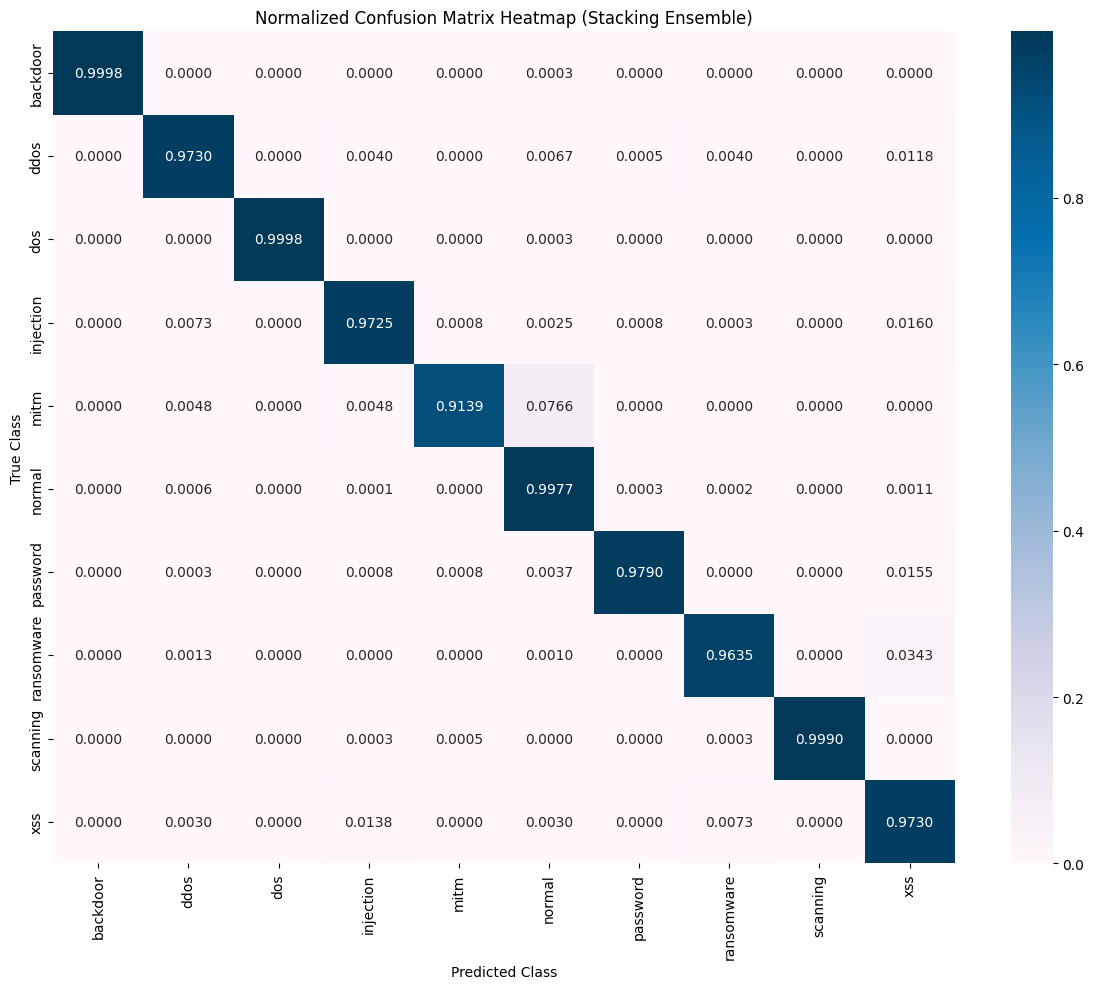


=== Detailed Classification Report (Per-Class Metrics) ===
              precision    recall  f1-score   support

    backdoor     1.0000    0.9998    0.9999      4000
        ddos     0.9784    0.9730    0.9757      4000
         dos     0.9998    0.9998    0.9998      4000
   injection     0.9798    0.9725    0.9762      4000
        mitm     0.9502    0.9139    0.9317       209
      normal     0.9986    0.9977    0.9981     60000
    password     0.9942    0.9790    0.9865      4000
  ransomware     0.9854    0.9635    0.9743      4000
    scanning     0.9995    0.9990    0.9992      4000
         xss     0.9123    0.9730    0.9417      4000

    accuracy                         0.9922     92209
   macro avg     0.9798    0.9771    0.9783     92209
weighted avg     0.9924    0.9922    0.9923     92209

--- Script Execution Complete ---


In [10]:
#Adaboost + XGB + LGBM
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    recall_score, 
    precision_score, 
    confusion_matrix,
    classification_report
)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =======================
# File path
# =======================
input_file = r"D:\Dataset_Project\dataset_fyp\10Features_multiclass_process\preprocess_merged_multiclass.csv"

# =======================
# Class sampling limits and Labels
# =======================
class_limits = {
    0: 20000, 1: 20000, 2: 20000, 3: 20000, 
    4: 1043, 5: 300000, 6: 20000, 7: 20000, 
    8: 20000, 9: 20000,
}
chunksize = 100000

# Define class labels for visualization and reporting
class_labels = {
    0: 'backdoor', 1: 'ddos', 2: 'dos', 3: 'injection', 
    4: 'mitm', 5: 'normal', 6: 'password', 7: 'ransomware', 
    8: 'scanning', 9: 'xss',
}
target_names = [class_labels[i] for i in sorted(class_labels.keys())]


# ###############################################################
# STEP 1: Data Sampling (Handling large CSV in chunks)
# ###############################################################
print("=== Step 1: Sampling rows per class from CSV in chunks ===")

selected_rows = {cls: [] for cls in class_limits}
row_count = {cls: 0 for cls in class_limits}

try:
    for chunk in pd.read_csv(input_file, chunksize=chunksize):
        for cls, limit in class_limits.items():
            if row_count[cls] >= limit:
                continue
            cls_rows = chunk[chunk['type'] == cls]
            if cls_rows.empty:
                continue
            needed = limit - row_count[cls]
            take_rows = cls_rows.iloc[:needed]
            selected_rows[cls].append(take_rows)
            row_count[cls] += len(take_rows)

    df_sample = pd.concat([pd.concat(rows) for rows in selected_rows.values()], ignore_index=True)
    df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

except FileNotFoundError:
    print(f"\nERROR: File not found at path: {input_file}")
    print("Please ensure the file path is correct and accessible.")
    exit()

# ###############################################################
# STEP 2 & 3: Prepare Data & Split
# ###############################################################
y = df_sample['type']
X = df_sample.drop(columns=['type'])

print("\nClass distribution after sampling:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Compute sample weights for imbalance 
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

# ###############################################################
# STEP 4 & 5: Model Initialization (Level 1 Models)
# ###############################################################
# Base Decision Tree for AdaBoost
base_dt = DecisionTreeClassifier(
    criterion='entropy', class_weight='balanced', random_state=42, 
    max_depth=17, min_samples_split=4, min_samples_leaf=2,
    max_features='sqrt', min_impurity_decrease=1e-7,
)

# AdaBoost Model 
ada = AdaBoostClassifier(
    estimator=base_dt, n_estimators=7000, learning_rate=0.1, 
    algorithm='SAMME', random_state=42
)

# XGBoost Model 
xgb = XGBClassifier(
    objective="multi:softprob", num_class=10, tree_method="hist", 
    booster="gbtree", n_estimators=800, learning_rate=0.05, max_depth=7, 
    min_child_weight=1, subsample=0.85, colsample_bytree=0.85, 
    gamma=0.1, reg_alpha=0.5, reg_lambda=1.0, n_jobs=-1, 
    random_state=42, eval_metric="mlogloss"
)

# LightGBM Model 
lgbm = LGBMClassifier(
    objective='multiclass', num_class=10, n_estimators=400, 
    learning_rate=0.07, max_depth=-1, num_leaves=60, min_data_in_leaf=30, 
    subsample=0.8, colsample_bytree=0.8, class_weight='balanced', 
    reg_lambda=1, n_jobs=-1, random_state=42
)

# Meta-Learner (Level 2 Model)
meta_learner = LogisticRegression(max_iter=2000, random_state=42, multi_class='multinomial')

# ###############################################################
# STEP 6 & 7: Training Base Models & Creating Meta Features
# ###############################################################
print("\nTraining base models...\n")
start_time = time.time()

# Train Level 1 models
ada.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)

train_time = time.time() - start_time

# Create Meta Features (Probabilities)
meta_X_train = np.column_stack([
    ada.predict_proba(X_train),
    xgb.predict_proba(X_train),
    lgbm.predict_proba(X_train)
])

meta_X_test = np.column_stack([
    ada.predict_proba(X_test),
    xgb.predict_proba(X_test),
    lgbm.predict_proba(X_test)
])

# ###############################################################
# STEP 8: Train Meta-Learner
# ###############################################################
meta_learner.fit(meta_X_train, y_train)

# ###############################################################
# STEP 9: Evaluate & Metrics
# ###############################################################
y_pred = meta_learner.predict(meta_X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("\n===== FINAL STACKING RESULTS (AdaBoost + XGB + LGBM) =====")
print(f"Training Time: {train_time:.2f} seconds")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")


# ###############################################################
# STEP 10: Visualization and Detailed Reporting
# ###############################################################

# --- 1. Confusion Matrix Heatmap ---
print("\n=== Generating Confusion Matrix Heatmap ===")

# Normalize the confusion matrix (rows sum to 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f', # Increased precision to 4 decimal places
    cmap='PuBu',
    cbar=True,
    xticklabels=target_names,
    yticklabels=target_names
)


plt.title('Normalized Confusion Matrix Heatmap (Stacking Ensemble)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show() 

# --- 2. Classification Metric Report ---
print("\n=== Detailed Classification Report (Per-Class Metrics) ===")

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4, # Increased precision to 4 decimal places
    zero_division=0
)
print(report)

print("--- Script Execution Complete ---")

=== Step 1: Sampling rows per class from CSV in chunks ===

Class distribution after sampling:
type
5    300000
6     20000
9     20000
3     20000
7     20000
2     20000
0     20000
1     20000
8     20000
4      1043
Name: count, dtype: int64

Training base models (GBT, XGB, LGBM)...

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1792
[LightGBM] [Info] Number of data points in the train set: 368834, number of used features: 10
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[Ligh

C:\Users\60105\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== FINAL STACKING RESULTS (GBT + XGB + LGBM) =====
Training Time: 4333.58 seconds
Accuracy: 0.9922
F1 Score: 0.9922
Recall: 0.9922
Precision: 0.9924

=== Generating Confusion Matrix Heatmap ===


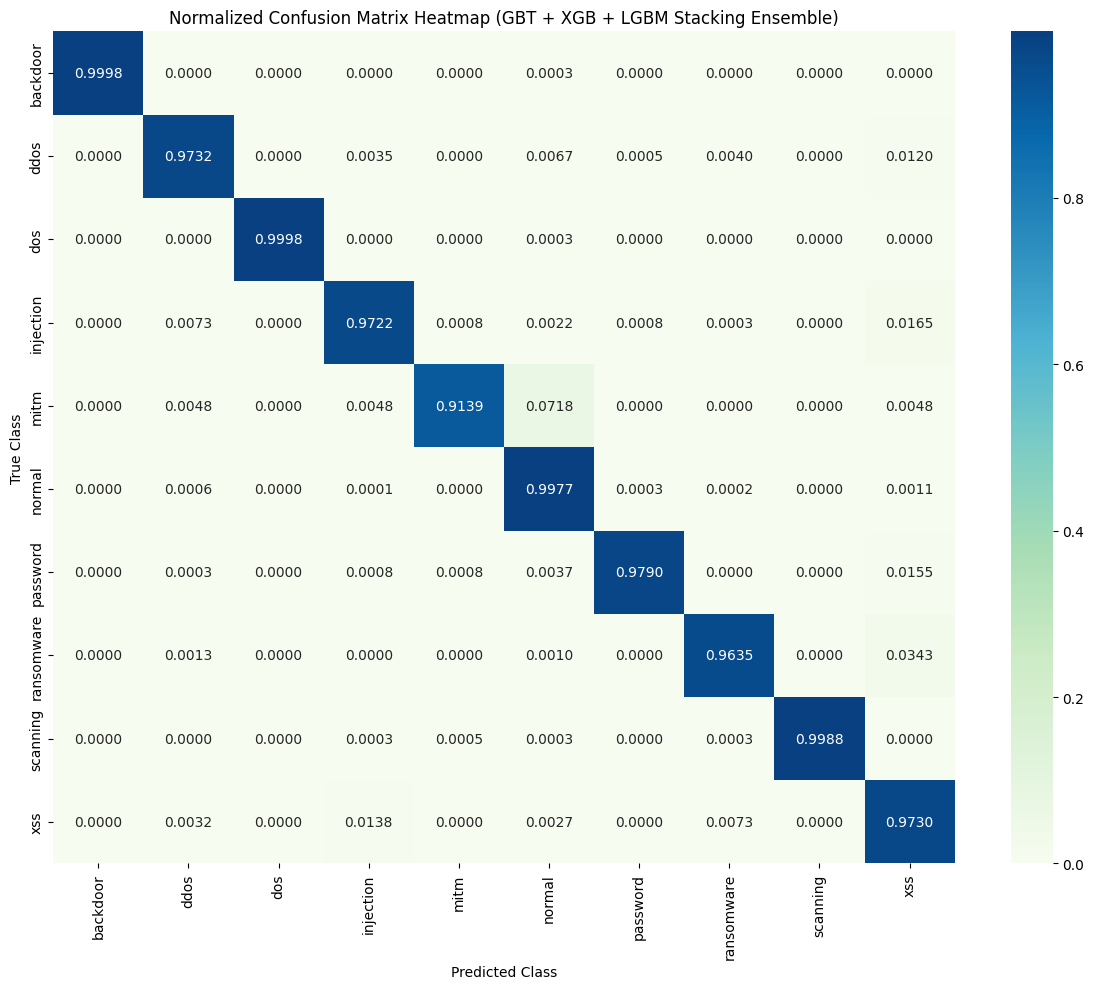


=== Detailed Classification Report (Per-Class Metrics) ===
              precision    recall  f1-score   support

    backdoor     1.0000    0.9998    0.9999      4000
        ddos     0.9779    0.9732    0.9756      4000
         dos     0.9998    0.9998    0.9998      4000
   injection     0.9801    0.9722    0.9762      4000
        mitm     0.9550    0.9139    0.9340       209
      normal     0.9986    0.9977    0.9981     60000
    password     0.9942    0.9790    0.9865      4000
  ransomware     0.9854    0.9635    0.9743      4000
    scanning     0.9995    0.9988    0.9991      4000
         xss     0.9115    0.9730    0.9412      4000

    accuracy                         0.9922     92209
   macro avg     0.9802    0.9771    0.9785     92209
weighted avg     0.9924    0.9922    0.9922     92209

--- Script Execution Complete ---


In [11]:
#GBT + XGB + LGBM
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    recall_score, 
    precision_score, 
    confusion_matrix,
    classification_report
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =======================
# File path
# =======================
input_file = r"D:\Dataset_Project\dataset_fyp\10Features_multiclass_process\preprocess_merged_multiclass.csv"

# =======================
# Class sampling limits and Labels
# =======================
class_limits = {
    0: 20000, 1: 20000, 2: 20000, 3: 20000, 
    4: 1043, 5: 300000, 6: 20000, 7: 20000, 
    8: 20000, 9: 20000,
}
chunksize = 100000

# Define class labels for visualization and reporting
class_labels = {
    0: 'backdoor', 1: 'ddos', 2: 'dos', 3: 'injection', 
    4: 'mitm', 5: 'normal', 6: 'password', 7: 'ransomware', 
    8: 'scanning', 9: 'xss',
}
target_names = [class_labels[i] for i in sorted(class_labels.keys())]


# ###############################################################
# STEP 1: Data Sampling (Handling large CSV in chunks)
# ###############################################################
print("=== Step 1: Sampling rows per class from CSV in chunks ===")

selected_rows = {cls: [] for cls in class_limits}
row_count = {cls: 0 for cls in class_limits}

try:
    for chunk in pd.read_csv(input_file, chunksize=chunksize):
        for cls, limit in class_limits.items():
            if row_count[cls] >= limit:
                continue
            cls_rows = chunk[chunk['type'] == cls]
            if cls_rows.empty:
                continue
            needed = limit - row_count[cls]
            take_rows = cls_rows.iloc[:needed]
            selected_rows[cls].append(take_rows)
            row_count[cls] += len(take_rows)

    df_sample = pd.concat([pd.concat(rows) for rows in selected_rows.values()], ignore_index=True)
    df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

except FileNotFoundError:
    print(f"\nERROR: File not found at path: {input_file}")
    print("Please ensure the file path is correct and accessible.")
    exit()

# ###############################################################
# STEP 2 & 3: Prepare Data & Split
# ###############################################################
y = df_sample['type']
X = df_sample.drop(columns=['type'])

print("\nClass distribution after sampling:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Compute sample weights (retained for context, but not explicitly passed to GBT/XGB/LGBM which handle imbalance via parameters or objective)
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

# ###############################################################
# STEP 4 & 5: Model Initialization (Level 1 Models)
# ###############################################################
# Gradient Boosting Classifier (Level 1)
gbt = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    max_features='sqrt',
    loss='log_loss',
    random_state=42
)

# XGBoost Model (Level 1)
xgb = XGBClassifier(
    objective="multi:softprob", num_class=10, tree_method="hist", 
    booster="gbtree", n_estimators=800, learning_rate=0.05, max_depth=7, 
    min_child_weight=1, subsample=0.85, colsample_bytree=0.85, 
    gamma=0.1, reg_alpha=0.5, reg_lambda=1.0, n_jobs=-1, 
    random_state=42, eval_metric="mlogloss"
)

# LightGBM Model (Level 1)
lgbm = LGBMClassifier(
    objective='multiclass', num_class=10, n_estimators=400, 
    learning_rate=0.07, max_depth=-1, num_leaves=60, min_data_in_leaf=30, 
    subsample=0.8, colsample_bytree=0.8, class_weight='balanced', 
    reg_lambda=1, n_jobs=-1, random_state=42
)

# Meta-Learner (Level 2 Model)
meta_learner = LogisticRegression(max_iter=2000, random_state=42, multi_class='multinomial')

# ###############################################################
# STEP 6 & 7: Training Base Models & Creating Meta Features
# ###############################################################
print("\nTraining base models (GBT, XGB, LGBM)...\n")
start_time = time.time()

# Train Level 1 models
gbt.fit(X_train, y_train) # GBT training
xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)

train_time = time.time() - start_time

# Create Meta Features (Probabilities)
# GBT replaces AdaBoost output
meta_X_train = np.column_stack([
    gbt.predict_proba(X_train), 
    xgb.predict_proba(X_train),
    lgbm.predict_proba(X_train)
])

meta_X_test = np.column_stack([
    gbt.predict_proba(X_test), 
    xgb.predict_proba(X_test),
    lgbm.predict_proba(X_test)
])

# ###############################################################
# STEP 8: Train Meta-Learner
# ###############################################################
meta_learner.fit(meta_X_train, y_train)

# ###############################################################
# STEP 9: Evaluate & Metrics
# ###############################################################
y_pred = meta_learner.predict(meta_X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("\n===== FINAL STACKING RESULTS (GBT + XGB + LGBM) =====")
print(f"Training Time: {train_time:.2f} seconds")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")


# ###############################################################
# STEP 10: Visualization and Detailed Reporting
# ###############################################################

# --- 1. Confusion Matrix Heatmap ---
print("\n=== Generating Confusion Matrix Heatmap ===")

# Normalize the confusion matrix (rows sum to 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f', # Increased precision to 4 decimal places
    cmap='GnBu', # New color map
    cbar=True,
    xticklabels=target_names,
    yticklabels=target_names
)


plt.title('Normalized Confusion Matrix Heatmap (GBT + XGB + LGBM Stacking Ensemble)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show() 

# --- 2. Classification Metric Report ---
print("\n=== Detailed Classification Report (Per-Class Metrics) ===")

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4, # Increased precision to 4 decimal places
    zero_division=0
)
print(report)

print("--- Script Execution Complete ---")